In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df1 = pd.read_csv('Base_Montee_des_eaux_bon.csv')
df1.columns

Index(['year_month', 'sea level corrected adjusted', 'chlorophylle',
       'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
       'antarctica_mass'],
      dtype='object')

In [3]:
df1['year_month'] = pd.to_datetime(df1['year_month'], format='%Y-%m-%d')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529 entries, 0 to 528
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   year_month                    529 non-null    datetime64[ns]
 1   sea level corrected adjusted  378 non-null    float64       
 2   chlorophylle                  328 non-null    float64       
 3   sst_anomaly_filtered          492 non-null    float64       
 4   CO2                           229 non-null    float64       
 5   salinité                      180 non-null    float64       
 6   greenland_mass                249 non-null    float64       
 7   antarctica_mass               249 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 33.2 KB


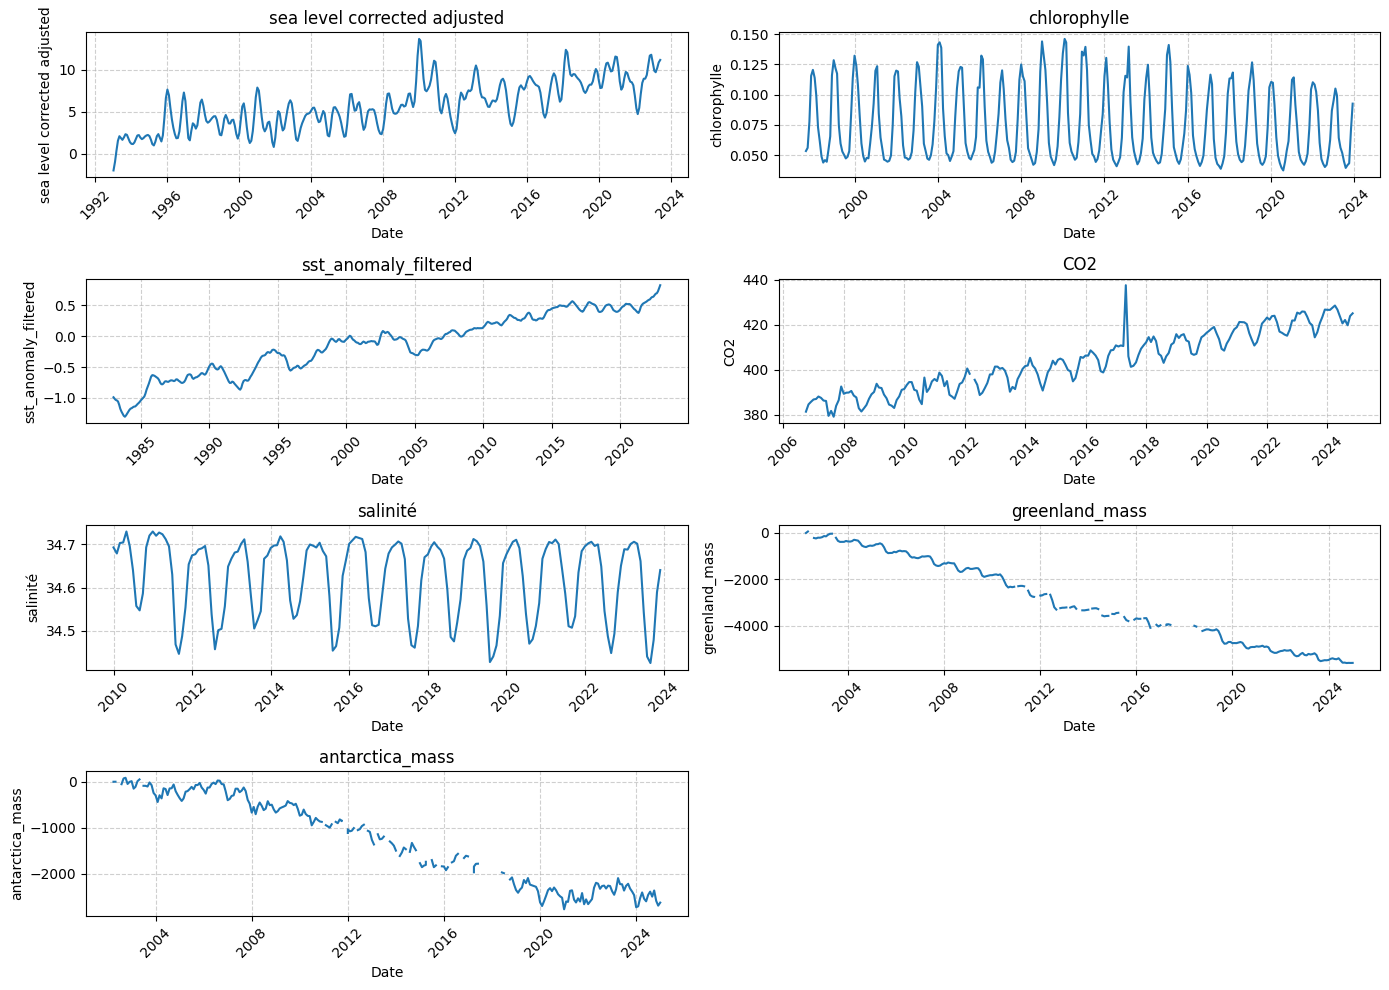

In [4]:
# Liste des colonnes à tracer
columns_to_plot = ['sea level corrected adjusted', 'chlorophylle',
                   'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
                   'antarctica_mass']

# Définir la taille de la figure
plt.figure(figsize=(14, 10))

# Tracer chaque colonne
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(len(columns_to_plot) // 2 + len(columns_to_plot) % 2, 2, i)
    plt.plot(df1['year_month'], df1[column], label=column, linewidth=1.5)
    plt.title(column, fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel(column, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

In [5]:
# Les valeurs manquantes
df1.isnull().sum()

year_month                        0
sea level corrected adjusted    151
chlorophylle                    201
sst_anomaly_filtered             37
CO2                             300
salinité                        349
greenland_mass                  280
antarctica_mass                 280
dtype: int64

In [6]:
df1.describe()

,year_month,sea level corrected adjusted,chlorophylle,sst_anomaly_filtered,CO2,salinité,greenland_mass,antarctica_mass
count,529,378.000000,328.000000,492.000000,229.000000,180.000000,249.000000,249.000000
mean,2003-09-27 13:25:44.801512320,5.694648,0.075458,-0.116031,403.691019,34.624715,-2892.439598,-1271.283976
min,1982-01-01 00:00:00,-1.991721,0.037348,-1.307222,379.080000,34.426174,-5614.000000,-2777.220000
25%,1993-01-01 00:00:00,3.565217,0.048836,-0.513125,392.346000,34.544989,-4706.240000,-2255.330000
50%,2004-01-01 00:00:00,5.471170,0.063420,-0.065445,403.047500,34.666631,-3206.860000,-1114.760000
75%,2014-07-01 00:00:00,7.863623,0.104431,0.300686,414.420000,34.697179,-1295.580000,-401.290000
max,2025-01-01 00:00:00,13.668426,0.146130,0.828921,437.583333,34.729313,63.950000,86.080000
std,NaN,2.841068,0.030555,0.487973,12.957528,0.088676,1782.559996,923.300999


In [7]:
# 3. Filtrer la période commune
df = df1[(df1['year_month'] >= '2010-01-01') & (df1['year_month'] <= '2022-12-01')]
df = df.sort_values('year_month')
df.head()

,year_month,sea level corrected adjusted,chlorophylle,sst_anomaly_filtered,CO2,salinité,greenland_mass,antarctica_mass
336,2010-01-01,13.668426,0.134212,0.146741,391.430000,34.692608,-1821.86,-739.09
337,2010-02-01,13.412240,0.146130,0.167043,393.227500,34.678696,-1798.05,-717.92
338,2010-03-01,11.343056,0.143185,0.189243,394.502500,34.702680,-1787.96,-605.84
339,2010-04-01,8.935583,0.084990,0.218566,394.480000,34.704070,-1815.11,-702.17
340,2010-05-01,7.603814,0.060147,0.234102,391.056667,34.729305,-1787.14,-742.25


In [8]:
df.isnull().sum()

year_month                       0
sea level corrected adjusted     0
chlorophylle                     0
sst_anomaly_filtered             0
CO2                              1
salinité                         0
greenland_mass                  34
antarctica_mass                 34
dtype: int64

In [9]:
df.describe()

,year_month,sea level corrected adjusted,chlorophylle,sst_anomaly_filtered,CO2,salinité,greenland_mass,antarctica_mass
count,168,168.000000,168.000000,168.000000,167.000000,168.000000,134.000000,134.000000
mean,2016-04-14 13:17:08.571428608,7.683789,0.074382,0.412855,404.942793,34.626099,-3769.623731,-1732.954254
min,2010-01-01 00:00:00,2.438800,0.037348,0.146741,384.677500,34.428410,-5320.740000,-2777.220000
25%,2012-12-24 06:00:00,6.352024,0.047817,0.291056,396.690000,34.545906,-4754.615000,-2303.630000
50%,2016-03-16 12:00:00,7.902162,0.063420,0.424941,404.397500,34.666759,-3723.940000,-1798.995000
75%,2019-06-08 12:00:00,9.132308,0.102140,0.503302,412.619750,34.697179,-3190.382500,-1097.405000
max,2022-12-01 00:00:00,13.668426,0.146130,0.828921,437.583333,34.729313,-1787.140000,-605.840000
std,NaN,2.278448,0.030551,0.130727,10.114424,0.087457,994.434383,624.844856


In [10]:
df.shape

(168, 8)

#### Correction des valeurs manquantes:

In [11]:
# Fonction pour remplacer les NaN par la moyenne des valeurs autour
def average_neighbors(series):
    series_corrected = series.copy()
    for i in range(1, len(series) - 1):
        if pd.isna(series.iloc[i]) and not pd.isna(series.iloc[i - 1]) and not pd.isna(series.iloc[i + 1]):
            series_corrected.iloc[i] = (series.iloc[i - 1] + series.iloc[i + 1]) / 2
    return series_corrected

# Appliquer la correction à la colonne CO2
df['CO2'] = average_neighbors(df['CO2'])
df['CO2'].isna().sum()  

0

In [12]:
# Liste des variables à interpoler
variables = [
    'sea level corrected adjusted',
    'sst_anomaly_filtered',
    'greenland_mass',
    'antarctica_mass'
]

# Interpolation linéaire des valeurs manquantes pour chaque variable
for var in variables:
    df[var] = df[var].interpolate(method='linear')
df.isna().sum()  # Vérifier les valeurs manquantes restantes

year_month                      0
sea level corrected adjusted    0
chlorophylle                    0
sst_anomaly_filtered            0
CO2                             0
salinité                        0
greenland_mass                  0
antarctica_mass                 0
dtype: int64

In [13]:
df1['CO2'] = df['CO2']
df1['sea level corrected adjusted'] = df['sea level corrected adjusted']
df1['sst_anomaly_filtered'] = df['sst_anomaly_filtered']
df1['greenland_mass'] = df['greenland_mass']
df1['antarctica_mass'] = df['antarctica_mass']

In [14]:
df.columns

Index(['year_month', 'sea level corrected adjusted', 'chlorophylle',
       'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
       'antarctica_mass'],
      dtype='object')

In [15]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Extrait les colonnes numériques
X = df.drop(columns='year_month').dropna()

# Test de Johansen (cointégration multivariée)
johan_test = coint_johansen(X, det_order=0, k_ar_diff=1)
print(johan_test.trace_stat)  # Statistique de trace
print(johan_test.trace_stat_crit_vals)  # Valeurs critiques

[372.06994348 238.96029562 135.08641331  73.52078977  35.90395201
  16.902767     3.02628376]
[[120.3673 125.6185 135.9825]
 [ 91.109   95.7542 104.9637]
 [ 65.8202  69.8189  77.8202]
 [ 44.4929  47.8545  54.6815]
 [ 27.0669  29.7961  35.4628]
 [ 13.4294  15.4943  19.9349]
 [  2.7055   3.8415   6.6349]]


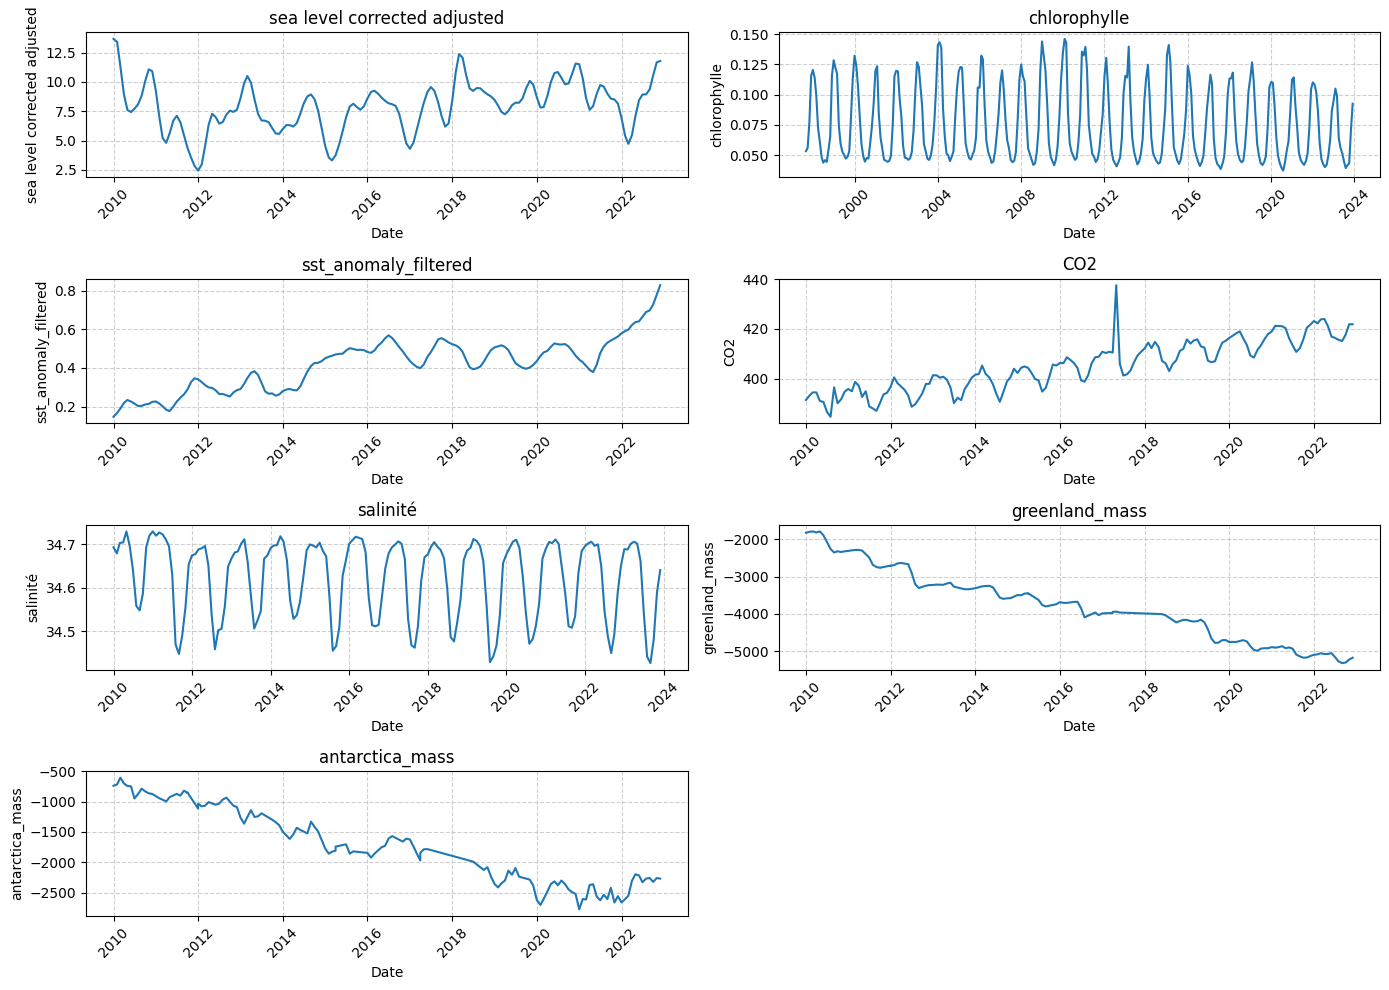

In [16]:
# Liste des colonnes à tracer
columns_to_plot = ['sea level corrected adjusted', 'chlorophylle',
                   'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
                   'antarctica_mass']

# Définir la taille de la figure
plt.figure(figsize=(14, 10))

# Tracer chaque colonne
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(len(columns_to_plot) // 2 + len(columns_to_plot) % 2, 2, i)
    plt.plot(df1['year_month'], df1[column], label=column, linewidth=1.5)
    plt.title(column, fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel(column, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

In [17]:
# Appliquer la différenciation saisonnière (X_t - X_{t-12})

for var in ['chlorophylle', 'CO2', 'salinité']:
    df[f'{var}_seasonal_diff'] = df[var] - df[var].shift(12)
df.columns


Index(['year_month', 'sea level corrected adjusted', 'chlorophylle',
       'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
       'antarctica_mass', 'chlorophylle_seasonal_diff', 'CO2_seasonal_diff',
       'salinité_seasonal_diff'],
      dtype='object')

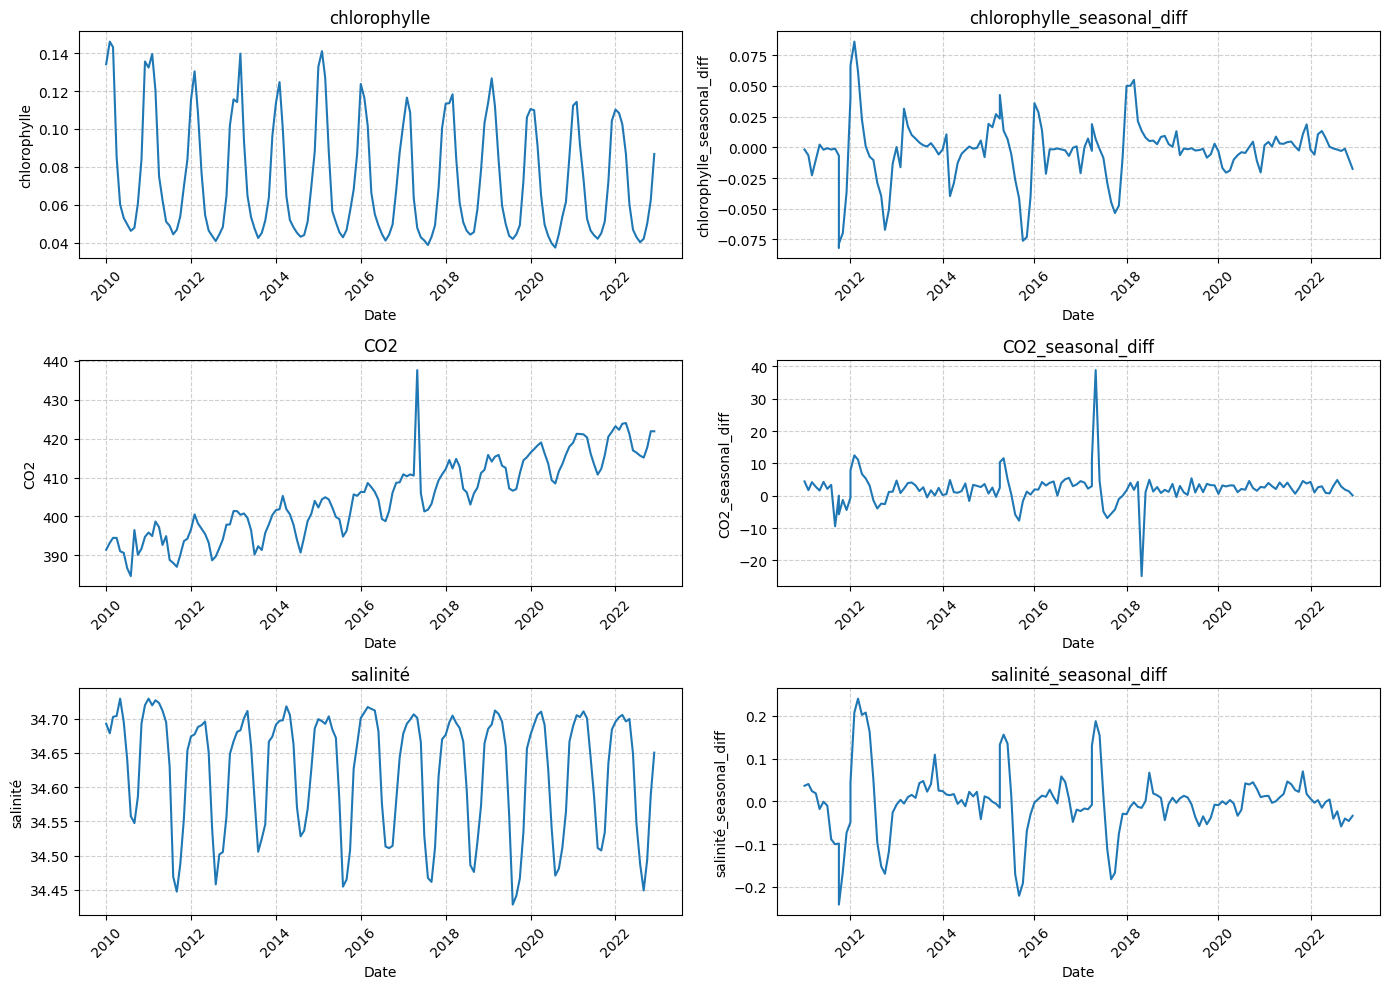

In [18]:
# Faire une comparaison entre les séries d'origine et les séries désaisonnalisées
columns_to_plot = ['chlorophylle','chlorophylle_seasonal_diff', 'CO2','CO2_seasonal_diff', 'salinité', 
                   'salinité_seasonal_diff' ]

plt.figure(figsize=(14, 10))


for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(len(columns_to_plot) // 2 + len(columns_to_plot) % 2, 2, i)
    plt.plot(df['year_month'], df[column], label=column, linewidth=1.5)
    plt.title(column, fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel(column, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

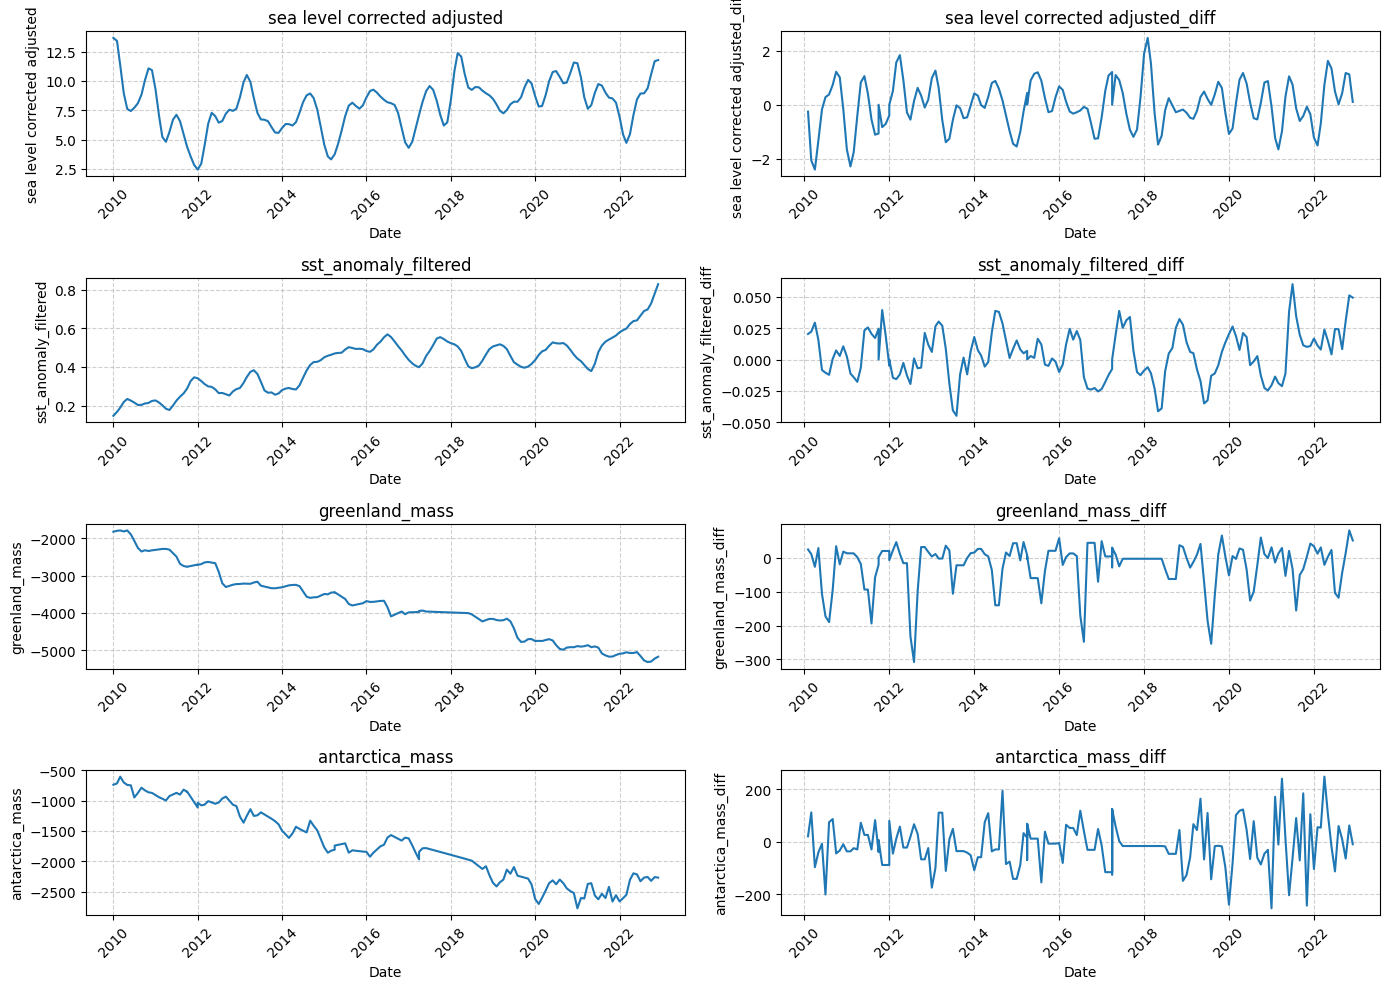

In [19]:
# Corriger la tendance des autres séries: différenciation simple (X_t - X_{t-1})
for var in ['sea level corrected adjusted', 'sst_anomaly_filtered', 'greenland_mass', 'antarctica_mass']:
    df[f'{var}_diff'] = df[var] - df[var].shift(1)


# Faire une comparaison entre les séries d'origine et les séries différenciées
columns_to_plot = ['sea level corrected adjusted','sea level corrected adjusted_diff', 
                   'sst_anomaly_filtered','sst_anomaly_filtered_diff', 
                   'greenland_mass','greenland_mass_diff', 
                   'antarctica_mass','antarctica_mass_diff']

plt.figure(figsize=(14, 10))


for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(len(columns_to_plot) // 2 + len(columns_to_plot) % 2, 2, i)
    plt.plot(df['year_month'], df[column], label=column, linewidth=1.5)
    plt.title(column, fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel(column, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()



In [20]:
df.isna().sum()  #

year_month                            0
sea level corrected adjusted          0
chlorophylle                          0
sst_anomaly_filtered                  0
CO2                                   0
salinité                              0
greenland_mass                        0
antarctica_mass                       0
chlorophylle_seasonal_diff           12
CO2_seasonal_diff                    12
salinité_seasonal_diff               12
sea level corrected adjusted_diff     1
sst_anomaly_filtered_diff             1
greenland_mass_diff                   1
antarctica_mass_diff                  1
dtype: int64

In [21]:
df.columns

Index(['year_month', 'sea level corrected adjusted', 'chlorophylle',
       'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
       'antarctica_mass', 'chlorophylle_seasonal_diff', 'CO2_seasonal_diff',
       'salinité_seasonal_diff', 'sea level corrected adjusted_diff',
       'sst_anomaly_filtered_diff', 'greenland_mass_diff',
       'antarctica_mass_diff'],
      dtype='object')

In [22]:
df.shape

(168, 15)

In [23]:
# Test de stationnarité des séries 

import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

# Liste des variables à tester
variables = [
    'sea level corrected adjusted', 
    'sst_anomaly_filtered', 
    'greenland_mass', 
    'antarctica_mass',
    'CO2', 
    'chlorophylle', 
    'salinité'
]

# Dictionnaire pour stocker les résultats
results = {}

for var in variables:
    series = df[var].dropna()

    # ADF Test
    adf_result = adfuller(series)
    adf_stats = {
        'ADF_stat': adf_result[0],
        'ADF_pvalue': adf_result[1]
    }

    # PP Test
    pp_result = PhillipsPerron(series)
    pp_stats = {
        'PP_stat': pp_result.stat,
        'PP_pvalue': pp_result.pvalue
    }

    # KPSS Test
    kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
    kpss_stats = {
        'KPSS_stat': kpss_stat,
        'KPSS_pvalue': kpss_pvalue
    }

    # Combiner les résultats
    results[var] = {**adf_stats, **pp_stats, **kpss_stats}

# Transformer en DataFrame
stationarity_results = pd.DataFrame(results).T

# Réorganiser les colonnes pour plus de lisibilité
stationarity_results = stationarity_results[[
    'ADF_pvalue',
    'PP_pvalue',
    'KPSS_pvalue'
]]

# Affichage du tableau
stationarity_results


C:\Users\HP\AppData\Local\Temp\ipykernel_4820\3739106047.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_4820\3739106047.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_4820\3739106047.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_4820\3739106047.py:39: InterpolationWarning:

,ADF_pvalue,PP_pvalue,KPSS_pvalue
sea level corrected adjusted,4.921310e-02,0.018079,0.032798
sst_anomaly_filtered,9.539361e-01,0.951580,0.010000
greenland_mass,6.808533e-01,0.464194,0.010000
antarctica_mass,6.303730e-01,0.597486,0.010000
CO2,9.716253e-01,0.240540,0.010000
chlorophylle,1.186253e-13,0.027173,0.100000
salinité,2.929113e-03,0.064445,0.100000


In [24]:
# Test de stationnarité des séries 

import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

# Liste des variables à tester
variables = [
    'sea level corrected adjusted_diff', 
    'sst_anomaly_filtered_diff', 
    'greenland_mass_diff', 
    'antarctica_mass_diff',
    'CO2_seasonal_diff', 
    'chlorophylle_seasonal_diff', 
    'salinité_seasonal_diff'
]

# Dictionnaire pour stocker les résultats
results = {}

for var in variables:
    series = df[var].dropna()

    # ADF Test
    adf_result = adfuller(series)
    adf_stats = {
        'ADF_stat': adf_result[0],
        'ADF_pvalue': adf_result[1]
    }

    # PP Test
    pp_result = PhillipsPerron(series)
    pp_stats = {
        'PP_stat': pp_result.stat,
        'PP_pvalue': pp_result.pvalue
    }

    # KPSS Test
    kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
    kpss_stats = {
        'KPSS_stat': kpss_stat,
        'KPSS_pvalue': kpss_pvalue
    }

    # Combiner les résultats
    results[var] = {**adf_stats, **pp_stats, **kpss_stats}

# Transformer en DataFrame
stationarity_results = pd.DataFrame(results).T

# Réorganiser les colonnes pour plus de lisibilité
stationarity_results = stationarity_results[[
    'ADF_pvalue',
    'PP_pvalue',
    'KPSS_pvalue'
]]

# Affichage du tableau
stationarity_results


C:\Users\HP\AppData\Local\Temp\ipykernel_4820\2934549070.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_4820\2934549070.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_4820\2934549070.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_4820\2934549070.py:39: InterpolationWarning:

,ADF_pvalue,PP_pvalue,KPSS_pvalue
sea level corrected adjusted_diff,1.187978e-05,1.093387e-03,0.1
sst_anomaly_filtered_diff,3.727968e-07,1.301770e-02,0.1
greenland_mass_diff,5.205656e-04,1.564738e-07,0.1
antarctica_mass_diff,5.502110e-02,8.081104e-27,0.1
CO2_seasonal_diff,4.517639e-03,3.332546e-12,0.1
chlorophylle_seasonal_diff,6.116917e-07,2.207908e-02,0.1
salinité_seasonal_diff,2.536372e-05,3.735237e-02,0.1


Au seuil de 5%, on conclut sur la stationnarité de nos variables!

In [25]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# Sélectionner les variables pour le test de causalité de Granger
var_df = df[[
    'sea level corrected adjusted',
    'sst_anomaly_filtered',
    'greenland_mass',
    'antarctica_mass',
    'CO2',
    'chlorophylle',
    'salinité'
]].dropna()

# Définir le nombre de retards (lags) pour le test
max_lags = 5

# Effectuer le test de causalité de Granger pour chaque paire de variables
for col in var_df.columns:
    for other_col in var_df.columns:
        if col != other_col:
            print(f'Testing Granger causality between {col} and {other_col}')
            test_result = grangercausalitytests(var_df[[col, other_col]], max_lags, verbose=False)
            for lag in range(1, max_lags + 1):
                p_value = test_result[lag][0]['ssr_ftest'][1]
                print(f'Lag {lag}: p-value = {p_value}')
            print('\n')


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Testing Granger causality between sea level corrected adjusted and sst_anomaly_filtered
Lag 1: p-value = 0.04128478937757556
Lag 2: p-value = 0.008344354545754927
Lag 3: p-value = 0.3022923664167136
Lag 4: p-value = 0.27955029698765466
Lag 5: p-value = 0.09374536893804683


Testing Granger causality between sea level corrected adjusted and greenland_mass
Lag 1: p-value = 0.007942161070777283
Lag 2: p-value = 0.0036221735998385705
Lag 3: p-value = 0.023340233688460162
Lag 4: p-value = 0.06511646579427001
Lag 5: p-value = 0.03838350721001596


Testing Granger causality between sea level corrected adjusted and antarctica_mass
Lag 1: p-value = 0.024969332077464008
Lag 2: p-value = 0.0010428120963873954
Lag 3: p-value = 0.039837720338269635
Lag 4: p-value = 0.06033260507010543
Lag 5: p-value = 0.0640958709371667


Testing Granger causality between sea level corrected adjusted and CO2
Lag 1: p-value = 0.008693780032212087
Lag 2: p-value = 0.0018202132236879828
Lag 3: p-value = 0.167996498653

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [26]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# Sélectionner les variables pour le test de causalité de Granger
var_df = df[[
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'antarctica_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Définir le nombre de retards (lags) pour le test
max_lags = 5

# Effectuer le test de causalité de Granger pour chaque paire de variables
for col in var_df.columns:
    for other_col in var_df.columns:
        if col != other_col:
            print(f'Testing Granger causality between {col} and {other_col}')
            test_result = grangercausalitytests(var_df[[col, other_col]], max_lags, verbose=False)
            for lag in range(1, max_lags + 1):
                p_value = test_result[lag][0]['ssr_ftest'][1]
                print(f'Lag {lag}: p-value = {p_value}')
            print('\n')


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Testing Granger causality between sea level corrected adjusted_diff and sst_anomaly_filtered_diff
Lag 1: p-value = 0.010648006857230899
Lag 2: p-value = 0.8570905788421268
Lag 3: p-value = 0.805133464131838
Lag 4: p-value = 0.23887487058450646
Lag 5: p-value = 0.6651090424827524


Testing Granger causality between sea level corrected adjusted_diff and greenland_mass_diff
Lag 1: p-value = 0.9275366307155255
Lag 2: p-value = 0.28463517056382254
Lag 3: p-value = 0.33146671986405807
Lag 4: p-value = 0.22997967774999595
Lag 5: p-value = 0.8189352112588038


Testing Granger causality between sea level corrected adjusted_diff and antarctica_mass_diff
Lag 1: p-value = 0.038166672273337296
Lag 2: p-value = 0.15818504463606256
Lag 3: p-value = 0.2825239005329647
Lag 4: p-value = 0.5681654318340752
Lag 5: p-value = 0.7199171500605264


Testing Granger causality between sea level corrected adjusted_diff and CO2_seasonal_diff
Lag 1: p-value = 0.11530661538130627
Lag 2: p-value = 0.7864005542623049


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag 1: p-value = 0.9946586783600034
Lag 2: p-value = 0.2632627855811643
Lag 3: p-value = 0.44027167696776903
Lag 4: p-value = 0.26259023571443313
Lag 5: p-value = 0.13628204894542742


Testing Granger causality between chlorophylle_seasonal_diff and greenland_mass_diff
Lag 1: p-value = 0.04277948475346996
Lag 2: p-value = 0.048010635094279705
Lag 3: p-value = 0.08427600778075202
Lag 4: p-value = 0.09063636039574398
Lag 5: p-value = 0.05920437232640821


Testing Granger causality between chlorophylle_seasonal_diff and antarctica_mass_diff
Lag 1: p-value = 0.2569385735463242
Lag 2: p-value = 0.5631961449512792
Lag 3: p-value = 0.49114078164605923
Lag 4: p-value = 0.5184437405634332
Lag 5: p-value = 0.2918543597878255


Testing Granger causality between chlorophylle_seasonal_diff and CO2_seasonal_diff
Lag 1: p-value = 0.4198051334668259
Lag 2: p-value = 0.2316162892740011
Lag 3: p-value = 0.10691153075902193
Lag 4: p-value = 0.02944415158352079
Lag 5: p-value = 0.004653814870132803


Test

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [27]:
from statsmodels.tsa.api import VAR
import pandas as pd

# Sélectionner les variables pour le VAR
var_df = df[[
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Étape 1 : Choix du nombre de retards (lags)
model = VAR(var_df)
lag_order_results = model.select_order(maxlags=12)
print("Lag selection criteria:\n", lag_order_results.summary())

# Étape 2 : Ajuster le modèle avec le lag optimal (ex: si AIC choisit 2 lags)
selected_lag = 2 # ou .bic, .hqic, selon ton critère préféré
var_model = model.fit(selected_lag)

# Étape 3 : Résumé du modèle
var_model.summary()


Lag selection criteria:
  VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -10.25      -10.12   3.550e-05      -10.20
1       -13.84      -12.98   9.747e-07      -13.49
2       -15.43     -13.82*   1.989e-07     -14.78*
3       -15.47      -13.12   1.930e-07      -14.51
4       -15.55      -12.45   1.808e-07      -14.29
5       -15.75      -11.91   1.508e-07      -14.19
6       -15.61      -11.03   1.790e-07      -13.75
7       -15.51      -10.19   2.049e-07      -13.35
8       -15.75      -9.691   1.705e-07      -13.29
9       -15.78      -8.975   1.790e-07      -13.02
10      -15.88      -8.335   1.780e-07      -12.82
11      -16.14      -7.846   1.562e-07      -12.77
12     -16.63*      -7.600  1.110e-07*      -12.96
--------------------------------------------------


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 20, May, 2025
Time:                     17:07:20
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -13.7859
Nobs:                     154.000    HQIC:                  -14.6993
Log likelihood:          -53.1422    FPE:                2.21753e-07
AIC:                     -15.3241    Det(Omega_mle):     1.36363e-07
--------------------------------------------------------------------
Results for equation sea level corrected adjusted_diff
                                          coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------------
const                                        0.006519         0.038652            0.169           0.866
L1.sea level corrected adjusted_diff        

In [28]:
df.head(15)

,year_month,sea level corrected adjusted,chlorophylle,sst_anomaly_filtered,CO2,salinité,greenland_mass,antarctica_mass,chlorophylle_seasonal_diff,CO2_seasonal_diff,salinité_seasonal_diff,sea level corrected adjusted_diff,sst_anomaly_filtered_diff,greenland_mass_diff,antarctica_mass_diff
336,2010-01-01,13.668426,0.134212,0.146741,391.430000,34.692608,-1821.86,-739.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
337,2010-02-01,13.412240,0.146130,0.167043,393.227500,34.678696,-1798.05,-717.92,NaN,NaN,NaN,-0.256185,0.020302,23.81,21.17
338,2010-03-01,11.343056,0.143185,0.189243,394.502500,34.702680,-1787.96,-605.84,NaN,NaN,NaN,-2.069184,0.022200,10.09,112.08
339,2010-04-01,8.935583,0.084990,0.218566,394.480000,34.704070,-1815.11,-702.17,NaN,NaN,NaN,-2.407474,0.029323,-27.15,-96.33
340,2010-05-01,7.603814,0.060147,0.234102,391.056667,34.729305,-1787.14,-742.25,NaN,NaN,NaN,-1.331768,0.015536,27.97,-40.08
341,2010-06-01,7.432775,0.052976,0.225713,390.655000,34.695500,-1893.93,-749.03,NaN,NaN,NaN,-0.171040,-0.008388,-106.79,-6.78
342,2010-07-01,7.712972,0.049594,0.215200,386.706000,34.639988,-2066.96,-949.22,NaN,NaN,NaN,0.280198,-0.010513,-173.03,-200.19
343,2010-08-01,8.094030,0.046181,0.203021,384.677500,34.557600,-2257.00,-874.52,NaN,NaN,NaN,0.381057,-0.012179,-190.04,74.70
344,2010-09-01,8.827926,0.047830,0.203446,396.504000,34.547516,-2353.05,-787.62,NaN,NaN,NaN,0.733896,0.000425,-96.05,86.90
345,2010-10-01,10.052702,0.060704,0.210670,390.113333,34.586340,-2319.62,-831.56,NaN,NaN,NaN,1.224776,0.007224,33.43,-43.94


In [29]:
from statsmodels.tsa.api import VAR
import pandas as pd

# Sélectionner les variables pour le VAR
var_df = df[[
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Étape 1 : Choix du nombre de retards (lags)
model = VAR(var_df)
lag_order_results = model.select_order(maxlags=12)
print("Lag selection criteria:\n", lag_order_results.summary())


var_model = model.fit(1)

# Étape 3 : Résumé du modèle
var_model.summary()


Lag selection criteria:
  VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -10.25      -10.12   3.550e-05      -10.20
1       -13.84      -12.98   9.747e-07      -13.49
2       -15.43     -13.82*   1.989e-07     -14.78*
3       -15.47      -13.12   1.930e-07      -14.51
4       -15.55      -12.45   1.808e-07      -14.29
5       -15.75      -11.91   1.508e-07      -14.19
6       -15.61      -11.03   1.790e-07      -13.75
7       -15.51      -10.19   2.049e-07      -13.35
8       -15.75      -9.691   1.705e-07      -13.29
9       -15.78      -8.975   1.790e-07      -13.02
10      -15.88      -8.335   1.780e-07      -12.82
11      -16.14      -7.846   1.562e-07      -12.77
12     -16.63*      -7.600  1.110e-07*      -12.96
--------------------------------------------------


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 20, May, 2025
Time:                     17:07:20
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -12.9372
Nobs:                     155.000    HQIC:                  -13.4269
Log likelihood:          -211.065    FPE:                1.05546e-06
AIC:                     -13.7619    Det(Omega_mle):     8.09734e-07
--------------------------------------------------------------------
Results for equation sea level corrected adjusted_diff
                                          coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------------
const                                        0.005194         0.056160            0.092           0.926
L1.sea level corrected adjusted_diff        

In [30]:
n = var_model.nobs  # nombre d'observations
k = var_model.neqs * var_model.k_ar  # nombre total de régressseurs

for i, col in enumerate(var_model.names):
    y_true = var_model.model.endog[var_model.k_ar:, i]  # valeurs observées (retards exclus)
    y_pred = var_model.fittedvalues.iloc[:, i]          # valeurs prédites via .iloc
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
    print(f"{col} :  R²= {r2:.4f} | R² ajusté = {r2_adj:.4f} ")


sea level corrected adjusted_diff :  R²= 0.5296 | R² ajusté = 0.5105 
sst_anomaly_filtered_diff :  R²= 0.6171 | R² ajusté = 0.6016 
greenland_mass_diff :  R²= 0.2898 | R² ajusté = 0.2610 
CO2_seasonal_diff :  R²= 0.2355 | R² ajusté = 0.2045 
chlorophylle_seasonal_diff :  R²= 0.6104 | R² ajusté = 0.5946 
salinité_seasonal_diff :  R²= 0.7242 | R² ajusté = 0.7131 


In [31]:
n = var_model.nobs  # nombre d'observations
k = var_model.neqs * var_model.k_ar  # nombre total de régressseurs

for i, col in enumerate(var_model.names):
    y_true = var_model.model.endog[var_model.k_ar:, i]  # valeurs observées (retards exclus)
    y_pred = var_model.fittedvalues.iloc[:, i]          # valeurs prédites via .iloc
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
    print(f"{col} :  R²= {r2:.4f} | R² ajusté = {r2_adj:.4f} ")


sea level corrected adjusted_diff :  R²= 0.5296 | R² ajusté = 0.5105 
sst_anomaly_filtered_diff :  R²= 0.6171 | R² ajusté = 0.6016 
greenland_mass_diff :  R²= 0.2898 | R² ajusté = 0.2610 
CO2_seasonal_diff :  R²= 0.2355 | R² ajusté = 0.2045 
chlorophylle_seasonal_diff :  R²= 0.6104 | R² ajusté = 0.5946 
salinité_seasonal_diff :  R²= 0.7242 | R² ajusté = 0.7131 


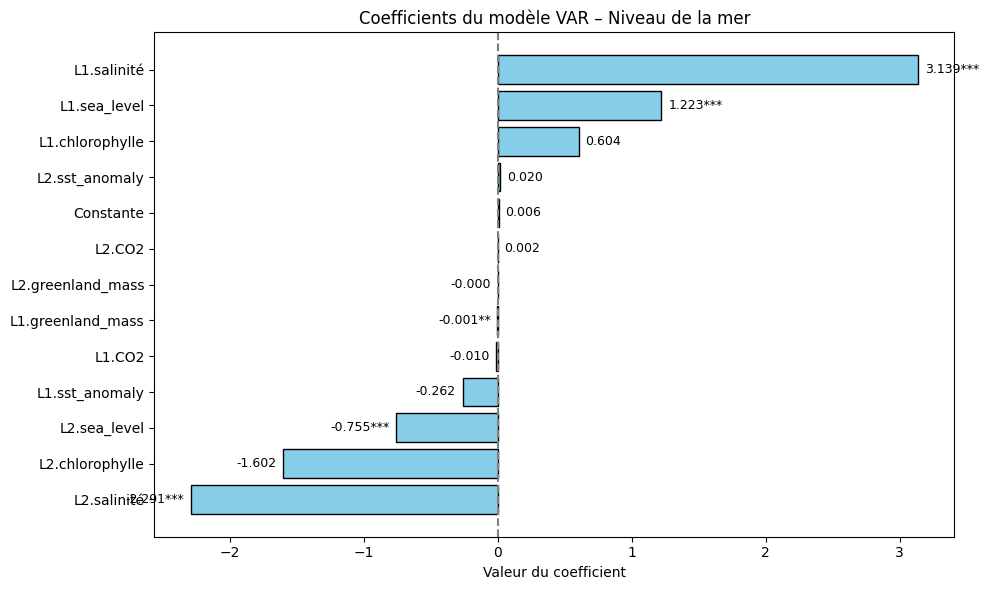

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Coefficients et p-values
data = {
    "Constante": (0.0065, 0.866),
    "L1.sea_level": (1.2231, 0.000),
    "L1.sst_anomaly": (-0.2621, 0.913),
    "L1.greenland_mass": (-0.0011, 0.042),
    "L1.CO2": (-0.0097, 0.206),
    "L1.chlorophylle": (0.6042, 0.743),
    "L1.salinité": (3.1387, 0.000),
    "L2.sea_level": (-0.7550, 0.000),
    "L2.sst_anomaly": (0.0201, 0.993),
    "L2.greenland_mass": (-0.0002, 0.649),
    "L2.CO2": (0.0019, 0.797),
    "L2.chlorophylle": (-1.6021, 0.399),
    "L2.salinité": (-2.291, 0.002)
}

# Extraire les coefficients et les p-values
labels = list(data.keys())
coeffs = [v[0] for v in data.values()]
pvals = [v[1] for v in data.values()]

# Déterminer les étoiles selon la significativité
stars = []
for p in pvals:
    if p < 0.01:
        stars.append('***')
    elif p < 0.05:
        stars.append('**')
    elif p < 0.1:
        stars.append('*')
    else:
        stars.append('')

# Créer le DataFrame
DF = pd.DataFrame({
    'Label': labels,
    'Coeff': coeffs,
    'Stars': stars
})
DF = DF.sort_values('Coeff')

# Tracer le graphique
plt.figure(figsize=(10, 6))
bars = plt.barh(DF['Label'], DF['Coeff'], color='skyblue', edgecolor='black')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title("Coefficients du modèle VAR – Niveau de la mer")
plt.xlabel("Valeur du coefficient")

# Ajouter les annotations
for i, (value, star) in enumerate(zip(DF['Coeff'], DF['Stars'])):
    plt.text(value + 0.05 if value >= 0 else value - 0.05,
             i,
             f'{value:.3f}{star}',
             va='center',
             ha='left' if value >= 0 else 'right',
             fontsize=9)

plt.tight_layout()
plt.show()


In [33]:
df.columns

Index(['year_month', 'sea level corrected adjusted', 'chlorophylle',
       'sst_anomaly_filtered', 'CO2', 'salinité', 'greenland_mass',
       'antarctica_mass', 'chlorophylle_seasonal_diff', 'CO2_seasonal_diff',
       'salinité_seasonal_diff', 'sea level corrected adjusted_diff',
       'sst_anomaly_filtered_diff', 'greenland_mass_diff',
       'antarctica_mass_diff'],
      dtype='object')

In [34]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# Sélection des variables pour le VAR
var_df = df[[ 
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Ajustement du modèle VAR avec 2 retards
model = VAR(var_df)
var_model = model.fit(2)

# Test de Ljung-Box pour vérifier l'absence d'autocorrélation des résidus
print('Résultats du test de Ljung-Box :')
for i, col in enumerate(var_df.columns):
    ljung_box_results = acorr_ljungbox(var_model.resid.iloc[:, i], lags=[2], return_df=True)
    print(f'\n{col} :')
    print(ljung_box_results)

# Test de normalité de Jarque-Bera pour chaque série de résidus
print('\nRésultats du test de Jarque-Bera :')
for i, col in enumerate(var_df.columns):
    jb_stat, jb_pvalue, _, _ = jarque_bera(var_model.resid.iloc[:, i])
    print(f'{col} : Statistique = {jb_stat:.3f}, p-value = {jb_pvalue:.3f}')

# Vérification de la stabilité du modèle VAR
stability = var_model.is_stable(verbose=True)

print(f'\nStabilité du modèle : {stability}')


Résultats du test de Ljung-Box :

sea level corrected adjusted_diff :
     lb_stat  lb_pvalue
2  17.680925   0.000145

sst_anomaly_filtered_diff :
    lb_stat  lb_pvalue
2  7.808614   0.020155

greenland_mass_diff :
    lb_stat  lb_pvalue
2  0.114769   0.944231

CO2_seasonal_diff :
    lb_stat  lb_pvalue
2  0.404638   0.816834

chlorophylle_seasonal_diff :
    lb_stat  lb_pvalue
2  1.855258    0.39549

salinité_seasonal_diff :
    lb_stat  lb_pvalue
2  0.482528   0.785634

Résultats du test de Jarque-Bera :
sea level corrected adjusted_diff : Statistique = 0.713, p-value = 0.700
sst_anomaly_filtered_diff : Statistique = 7.933, p-value = 0.019
greenland_mass_diff : Statistique = 35.540, p-value = 0.000
CO2_seasonal_diff : Statistique = 6270.465, p-value = 0.000
chlorophylle_seasonal_diff : Statistique = 29.308, p-value = 0.000
salinité_seasonal_diff : Statistique = 42.693, p-value = 0.000
Eigenvalues of VAR(1) rep
0.2638739183306619
0.2638739183306619
0.8488522520042655
0.84885225200426

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [35]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# Sélection des variables pour le VAR
var_df = df[[ 
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Ajustement du modèle VAR avec 2 retards
model = VAR(var_df)
var_model = model.fit(1)

# Test de Ljung-Box pour vérifier l'absence d'autocorrélation des résidus
print('Résultats du test de Ljung-Box :')
for i, col in enumerate(var_df.columns):
    ljung_box_results = acorr_ljungbox(var_model.resid.iloc[:, i], lags=[2], return_df=True)
    print(f'\n{col} :')
    print(ljung_box_results)

# Test de normalité de Jarque-Bera pour chaque série de résidus
print('\nRésultats du test de Jarque-Bera :')
for i, col in enumerate(var_df.columns):
    jb_stat, jb_pvalue, _, _ = jarque_bera(var_model.resid.iloc[:, i])
    print(f'{col} : Statistique = {jb_stat:.3f}, p-value = {jb_pvalue:.3f}')

# Vérification de la stabilité du modèle VAR
stability = var_model.is_stable(verbose=True)
print(f'\nStabilité du modèle : {stability}')


Résultats du test de Ljung-Box :

sea level corrected adjusted_diff :
     lb_stat     lb_pvalue
2  47.772699  4.229512e-11

sst_anomaly_filtered_diff :
     lb_stat  lb_pvalue
2  14.218036   0.000818

greenland_mass_diff :
     lb_stat  lb_pvalue
2  10.853158   0.004398

CO2_seasonal_diff :
    lb_stat  lb_pvalue
2  1.317839    0.51741

chlorophylle_seasonal_diff :
     lb_stat  lb_pvalue
2  12.524898   0.001907

salinité_seasonal_diff :
     lb_stat  lb_pvalue
2  22.360816   0.000014

Résultats du test de Jarque-Bera :
sea level corrected adjusted_diff : Statistique = 0.151, p-value = 0.927
sst_anomaly_filtered_diff : Statistique = 8.739, p-value = 0.013
greenland_mass_diff : Statistique = 73.996, p-value = 0.000
CO2_seasonal_diff : Statistique = 6586.430, p-value = 0.000
chlorophylle_seasonal_diff : Statistique = 134.097, p-value = 0.000
salinité_seasonal_diff : Statistique = 25.808, p-value = 0.000
Eigenvalues of VAR(1) rep
0.11835892815347276
0.7666074403957293
0.7666074403957293


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [36]:
n = var_model.nobs  # nombre d'observations
k = var_model.neqs * var_model.k_ar  # nombre total de régressseurs

for i, col in enumerate(var_model.names):
    y_true = var_model.model.endog[var_model.k_ar:, i]  # valeurs observées (retards exclus)
    y_pred = var_model.fittedvalues.iloc[:, i]          # valeurs prédites via .iloc
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
    print(f"{col} :  R²= {r2:.4f} | R² ajusté = {r2_adj:.4f} ")


sea level corrected adjusted_diff :  R²= 0.5296 | R² ajusté = 0.5105 
sst_anomaly_filtered_diff :  R²= 0.6171 | R² ajusté = 0.6016 
greenland_mass_diff :  R²= 0.2898 | R² ajusté = 0.2610 
CO2_seasonal_diff :  R²= 0.2355 | R² ajusté = 0.2045 
chlorophylle_seasonal_diff :  R²= 0.6104 | R² ajusté = 0.5946 
salinité_seasonal_diff :  R²= 0.7242 | R² ajusté = 0.7131 


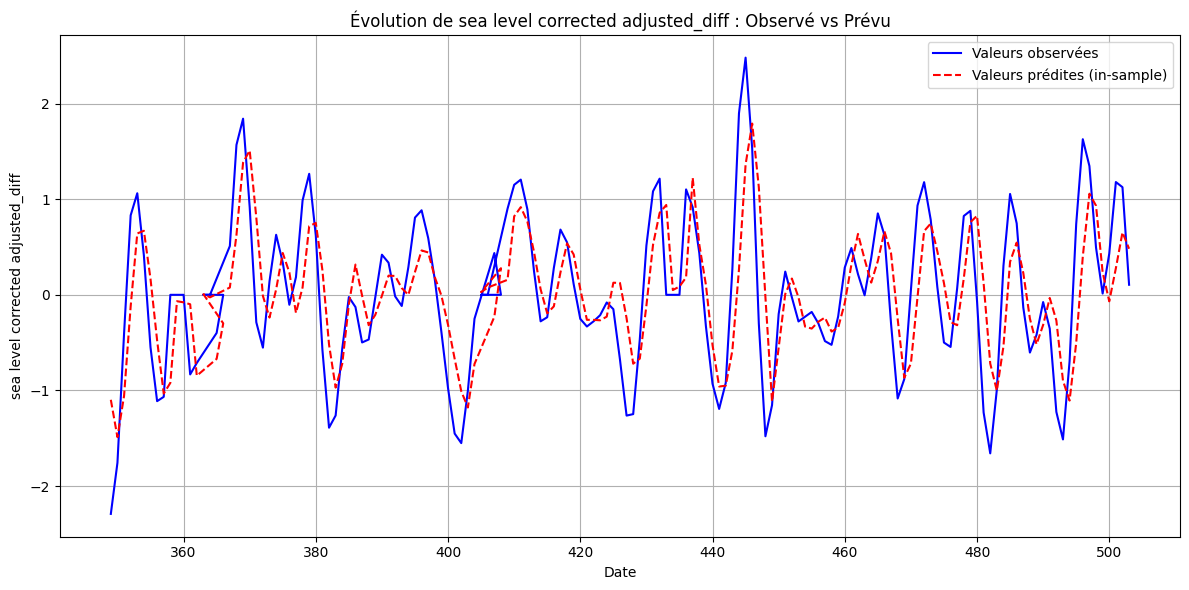

In [37]:
import matplotlib.pyplot as plt

# Variable cible
target_variable = 'sea level corrected adjusted_diff'

# Indices temporels alignés (exclure les premiers retards pour l'ajustement)
aligned_index = var_df.index[var_model.k_ar:]

# Extraire les séries observées et prédites
observed = var_df[target_variable].iloc[var_model.k_ar:]
predicted = var_model.fittedvalues[target_variable]

# Tracé
plt.figure(figsize=(12, 6))
plt.plot(aligned_index, observed, label='Valeurs observées', color='blue')
plt.plot(aligned_index, predicted, label='Valeurs prédites (in-sample)', color='red', linestyle='--')

plt.title(f"Évolution de {target_variable} : Observé vs Prévu")
plt.xlabel("Date")
plt.ylabel(target_variable)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

# Suppose que var_df est prêt (données différenciées et sans NA)
# Découpage en ensemble d'entraînement et de test
n_obs = 12  # nombre d'observations pour tester le modèle
train, test = var_df[:-n_obs], var_df[-n_obs:]

# Initialisation du modèle
model = VAR(train)

# Estimation VAR(1) et VAR(2)
var1 = model.fit(1)
var2 = model.fit(2)

# Prévision à 12 pas (ou autant que len(test))
forecast_var1 = var1.forecast(train.values[-1:], steps=n_obs)
forecast_var2 = var2.forecast(train.values[-2:], steps=n_obs)

# RMSE pour chaque modèle
rmse_var1 = np.sqrt(mean_squared_error(test, forecast_var1))
rmse_var2 = np.sqrt(mean_squared_error(test, forecast_var2))

# Affichage des critères
print("=== Critères d'information ===")
print("VAR(1) AIC  :", var1.aic)
print("VAR(1) BIC  :", var1.bic)
print("VAR(1) HQIC :", var1.hqic)

print("\nVAR(2) AIC  :", var2.aic)
print("VAR(2) BIC  :", var2.bic)
print("VAR(2) HQIC :", var2.hqic)

print("\n=== Précision de prévision ===")
print("VAR(1) RMSE :", rmse_var1)
print("VAR(2) RMSE :", rmse_var2)


=== Critères d'information ===
VAR(1) AIC  : -13.601471549619529
VAR(1) BIC  : -12.731265434438296
VAR(1) HQIC : -13.247861454497272

VAR(2) AIC  : -15.18669265059935
VAR(2) BIC  : -13.563069337269079
VAR(2) HQIC : -14.526918041126203

=== Précision de prévision ===
VAR(1) RMSE : 22.960698209445713
VAR(2) RMSE : 22.941950386515124


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [39]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

# Variables initiales
variables = [
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'antarctica_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]

# Scénarios à tester (nom, variables à exclure)
tests = [
    ("Modèle complet", []),
    ("Sans SST", ['sst_anomaly_filtered_diff']),
    ("Sans Chlorophylle", ['chlorophylle_seasonal_diff']),
    ("Sans CO2", ['CO2_seasonal_diff']),
    ("Sans Antarctica", ['antarctica_mass_diff']),
    ("Sans les 4 (SST, Chlorophylle, CO2, Antarctica)", [
        'sst_anomaly_filtered_diff',
        'chlorophylle_seasonal_diff',
        'CO2_seasonal_diff',
        'antarctica_mass_diff'
    ])
]

# Taille train/test
n_obs = int(len(df) * 0.8)

results = []

for label, excluded in tests:
    included_vars = [v for v in variables if v not in excluded]
    
    # Données
    var_df = df[included_vars].dropna()
    train = var_df.iloc[:n_obs]
    test = var_df.iloc[n_obs:]
    
    # Estimation du modèle VAR
    model = VAR(train)
    var_model = model.fit(2)
    
    # Prévision
    forecast = var_model.forecast(train.values[-2:], steps=len(test))
    forecast_df = pd.DataFrame(forecast, index=test.index, columns=test.columns)
    
    # RMSE sur la variable cible Y
    y_true = test['sea level corrected adjusted_diff']
    y_pred = forecast_df['sea level corrected adjusted_diff']
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Résultats
    results.append({
        'Modèle': label,
        'AIC': var_model.aic,
        'BIC': var_model.bic,
        'RMSE prévision Y': rmse
    })

# Résumé
results_df = pd.DataFrame(results)
results_df


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packag

,Modèle,AIC,BIC,RMSE prévision Y
0,Modèle complet,-6.161625,-3.868487,0.826928
1,Sans SST,2.757652,4.461126,0.822943
2,Sans Chlorophylle,2.162542,3.866016,0.827862
3,Sans CO2,-9.069595,-7.366121,0.827643
4,Sans Antarctica,-15.082292,-13.378818,0.817412
5,"Sans les 4 (SST, Chlorophylle, CO2, Antarctica)",-0.672454,-0.213826,0.815975


In [40]:
from statsmodels.tsa.api import VAR
import pandas as pd

# Sélectionner les variables pour le VAR
var_df = df[[
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Étape 1 : Choix du nombre de retards (lags)
model = VAR(var_df)
lag_order_results = model.select_order(maxlags=12)
print("Lag selection criteria:\n", lag_order_results.summary())

# Étape 2 : Ajuster le modèle avec le lag optimal (ex: si AIC choisit 2 lags)
selected_lag = 2 # ou .bic, .hqic, selon ton critère préféré
var_model = model.fit(selected_lag)

# Étape 3 : Résumé du modèle
var_model.summary()


Lag selection criteria:
  VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -10.25      -10.12   3.550e-05      -10.20
1       -13.84      -12.98   9.747e-07      -13.49
2       -15.43     -13.82*   1.989e-07     -14.78*
3       -15.47      -13.12   1.930e-07      -14.51
4       -15.55      -12.45   1.808e-07      -14.29
5       -15.75      -11.91   1.508e-07      -14.19
6       -15.61      -11.03   1.790e-07      -13.75
7       -15.51      -10.19   2.049e-07      -13.35
8       -15.75      -9.691   1.705e-07      -13.29
9       -15.78      -8.975   1.790e-07      -13.02
10      -15.88      -8.335   1.780e-07      -12.82
11      -16.14      -7.846   1.562e-07      -12.77
12     -16.63*      -7.600  1.110e-07*      -12.96
--------------------------------------------------


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 20, May, 2025
Time:                     17:07:21
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -13.7859
Nobs:                     154.000    HQIC:                  -14.6993
Log likelihood:          -53.1422    FPE:                2.21753e-07
AIC:                     -15.3241    Det(Omega_mle):     1.36363e-07
--------------------------------------------------------------------
Results for equation sea level corrected adjusted_diff
                                          coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------------
const                                        0.006519         0.038652            0.169           0.866
L1.sea level corrected adjusted_diff        

In [41]:
n = var_model.nobs  # nombre d'observations
k = var_model.neqs * var_model.k_ar  # nombre total de régressseurs

for i, col in enumerate(var_model.names):
    y_true = var_model.model.endog[var_model.k_ar:, i]  # valeurs observées (retards exclus)
    y_pred = var_model.fittedvalues.iloc[:, i]          # valeurs prédites via .iloc
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
    print(f"{col} :  R²= {r2:.4f} | R² ajusté = {r2_adj:.4f} ")


sea level corrected adjusted_diff :  R²= 0.8267 | R² ajusté = 0.8119 
sst_anomaly_filtered_diff :  R²= 0.6727 | R² ajusté = 0.6448 
greenland_mass_diff :  R²= 0.4184 | R² ajusté = 0.3689 
CO2_seasonal_diff :  R²= 0.3606 | R² ajusté = 0.3062 
chlorophylle_seasonal_diff :  R²= 0.7198 | R² ajusté = 0.6959 
salinité_seasonal_diff :  R²= 0.8056 | R² ajusté = 0.7891 


In [42]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# Sélection des variables pour le VAR
var_df = df[[ 
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Ajustement du modèle VAR avec 2 retards
model = VAR(var_df)
var_model = model.fit(2)

# Test de Ljung-Box pour vérifier l'absence d'autocorrélation des résidus
print('Résultats du test de Ljung-Box :')
for i, col in enumerate(var_df.columns):
    ljung_box_results = acorr_ljungbox(var_model.resid.iloc[:, i], lags=[2], return_df=True)
    print(f'\n{col} :')
    print(ljung_box_results)

# Test de normalité de Jarque-Bera pour chaque série de résidus
print('\nRésultats du test de Jarque-Bera :')
for i, col in enumerate(var_df.columns):
    jb_stat, jb_pvalue, _, _ = jarque_bera(var_model.resid.iloc[:, i])
    print(f'{col} : Statistique = {jb_stat:.3f}, p-value = {jb_pvalue:.3f}')

# Vérification de la stabilité du modèle VAR
stability = var_model.is_stable(verbose=True)
print(f'\nStabilité du modèle : {stability}')


Résultats du test de Ljung-Box :

sea level corrected adjusted_diff :
     lb_stat  lb_pvalue
2  17.680925   0.000145

sst_anomaly_filtered_diff :
    lb_stat  lb_pvalue
2  7.808614   0.020155

greenland_mass_diff :
    lb_stat  lb_pvalue
2  0.114769   0.944231

CO2_seasonal_diff :
    lb_stat  lb_pvalue
2  0.404638   0.816834

chlorophylle_seasonal_diff :
    lb_stat  lb_pvalue
2  1.855258    0.39549

salinité_seasonal_diff :
    lb_stat  lb_pvalue
2  0.482528   0.785634

Résultats du test de Jarque-Bera :
sea level corrected adjusted_diff : Statistique = 0.713, p-value = 0.700
sst_anomaly_filtered_diff : Statistique = 7.933, p-value = 0.019
greenland_mass_diff : Statistique = 35.540, p-value = 0.000
CO2_seasonal_diff : Statistique = 6270.465, p-value = 0.000
chlorophylle_seasonal_diff : Statistique = 29.308, p-value = 0.000
salinité_seasonal_diff : Statistique = 42.693, p-value = 0.000
Eigenvalues of VAR(1) rep
0.2638739183306619
0.2638739183306619
0.8488522520042655
0.84885225200426

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


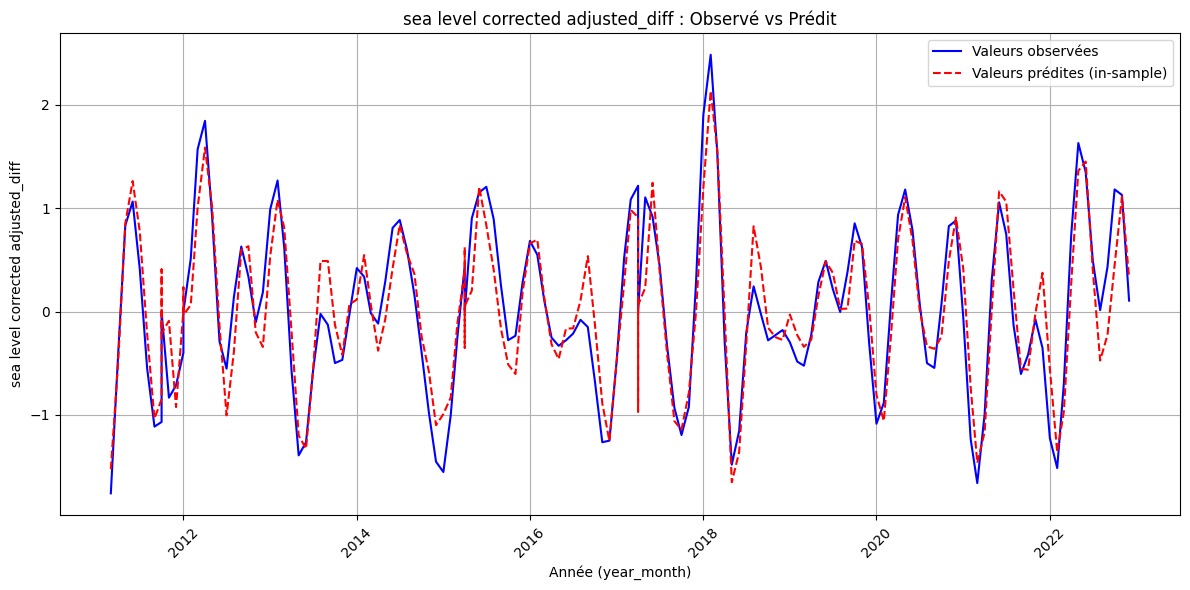

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Assurez-vous que 'year_month' est converti en datetime dans df
df['year_month'] = pd.to_datetime(df['year_month'])

# Sélectionner les variables pour le VAR
var_df = df[[
    'year_month',
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Ajuster le modèle VAR avec un lag de 2
model = VAR(var_df.drop(columns=['year_month']))
var_model = model.fit(2)

# Index temporel aligné (exclure les retards initiaux)
aligned_index = var_df['year_month'].iloc[var_model.k_ar:]

# Valeurs observées et prédites
target_variable = 'sea level corrected adjusted_diff'
observed = var_df[target_variable].iloc[var_model.k_ar:]
predicted = var_model.fittedvalues[target_variable]


# Tracé
plt.figure(figsize=(12, 6))
plt.plot(aligned_index, observed, label='Valeurs observées', color='blue')
plt.plot(aligned_index, predicted, label='Valeurs prédites (in-sample)', color='red', linestyle='--')

plt.title(f"{target_variable} : Observé vs Prédit")
plt.xlabel("Année (year_month)")
plt.ylabel(target_variable)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
import pandas as pd
import numpy as np

# Coefficients du modèle VAR
beta_0 = 0.006519
beta_1 = 1.223143
beta_2 = -0.262089
beta_3 = -0.001065
beta_4 = -0.009692
beta_5 = 0.604230
beta_6 = 3.138696
gamma_1 = -0.755013
gamma_2 = 0.020084
gamma_3 = -0.000239
gamma_4 = 0.001927
gamma_5 = -1.602122
gamma_6 = -2.291199

# Sélectionner les variables pour le VAR
var_df = df[[
    'year_month',
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Ajuster le modèle VAR avec un lag de 2
model = VAR(var_df.drop(columns=['year_month']))
var_model = model.fit(2)

# Calculer les valeurs différenciées prédictes
predicted_diff = beta_0 + beta_1 * var_df['sea level corrected adjusted_diff'].shift(1) + \
                 beta_2 * var_df['sst_anomaly_filtered_diff'].shift(1) + \
                 beta_3 * var_df['greenland_mass_diff'].shift(1) + \
                 beta_4 * var_df['CO2_seasonal_diff'].shift(1) + \
                 beta_5 * var_df['chlorophylle_seasonal_diff'].shift(1) + \
                 beta_6 * var_df['salinité_seasonal_diff'].shift(1) + \
                 gamma_1 * var_df['sea level corrected adjusted_diff'].shift(2) + \
                 gamma_2 * var_df['sst_anomaly_filtered_diff'].shift(2) + \
                 gamma_3 * var_df['greenland_mass_diff'].shift(2) + \
                 gamma_4 * var_df['CO2_seasonal_diff'].shift(2) + \
                 gamma_5 * var_df['chlorophylle_seasonal_diff'].shift(2) + \
                 gamma_6 * var_df['salinité_seasonal_diff'].shift(2)

# Convertir les valeurs différenciées en niveaux
predicted_levels = df['sea level corrected adjusted'].shift(1) + predicted_diff

# Ajouter les valeurs prédites au DataFrame
df['predicted_sea_level_corrected_adjusted'] = predicted_levels

# Afficher les résultats
df[['year_month', 'sea level corrected adjusted', 'predicted_sea_level_corrected_adjusted']]


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


,year_month,sea level corrected adjusted,predicted_sea_level_corrected_adjusted
336,2010-01-01,13.668426,NaN
337,2010-02-01,13.412240,NaN
338,2010-03-01,11.343056,NaN
339,2010-04-01,8.935583,NaN
340,2010-05-01,7.603814,NaN
...,...,...,...
499,2022-08-01,8.939324,8.452107
500,2022-09-01,9.370107,8.713459
501,2022-10-01,10.550028,9.819452
502,2022-11-01,11.676192,11.662372


In [45]:
predicted_levels

336          NaN
337          NaN
338          NaN
339          NaN
340          NaN
         ...    
499     8.452107
500     8.713459
501     9.819452
502    11.662372
503    12.003074
Length: 168, dtype: float64

In [46]:
predicted_levels.isna().sum()

14

In [47]:
# Prédiction de 'sst_anomaly_filtered_diff'
var_df['sst_anomaly_filtered_diff_pred'] = (
    0.000992 + 
    0.005334 * var_df['sea level corrected adjusted_diff'].shift(1) + 
    0.963882 * var_df['sst_anomaly_filtered_diff'].shift(1) + 
    0.000009 * var_df['greenland_mass_diff'].shift(1) + 
    0.000144 * var_df['CO2_seasonal_diff'].shift(1) + 
    0.023015 * var_df['chlorophylle_seasonal_diff'].shift(1) - 
    0.015259 * var_df['salinité_seasonal_diff'].shift(1) - 
    0.003585 * var_df['sea level corrected adjusted_diff'].shift(2) - 
    0.284295 * var_df['sst_anomaly_filtered_diff'].shift(2) - 
    0.000016 * var_df['greenland_mass_diff'].shift(2) - 
    0.000147 * var_df['CO2_seasonal_diff'].shift(2) - 
    0.084717 * var_df['chlorophylle_seasonal_diff'].shift(2) + 
    0.026357 * var_df['salinité_seasonal_diff'].shift(2)
)

# Prédiction de 'greenland_mass_diff'
var_df['greenland_mass_diff_pred'] = (
    -17.325752 + 
    6.174274 * var_df['sea level corrected adjusted_diff'].shift(1) + 
    -206.404412 * var_df['sst_anomaly_filtered_diff'].shift(1) + 
    0.583559 * var_df['greenland_mass_diff'].shift(1) + 
    -0.054548 * var_df['CO2_seasonal_diff'].shift(1) + 
    -164.579032 * var_df['chlorophylle_seasonal_diff'].shift(1) + 
    105.673857 * var_df['salinité_seasonal_diff'].shift(1) + 
    -15.690535 * var_df['sea level corrected adjusted_diff'].shift(2) + 
    397.424060 * var_df['sst_anomaly_filtered_diff'].shift(2) + 
    -0.319355 * var_df['greenland_mass_diff'].shift(2) + 
    0.986985 * var_df['CO2_seasonal_diff'].shift(2) + 
    501.834761 * var_df['chlorophylle_seasonal_diff'].shift(2) + 
    -323.361764 * var_df['salinité_seasonal_diff'].shift(2)
)

# Prédiction de 'CO2_seasonal_diff'
var_df['CO2_seasonal_diff_pred'] = (
    -0.009809 + 
    0.001889 * var_df['sea level corrected adjusted_diff'].shift(1) + 
    0.633380 * var_df['sst_anomaly_filtered_diff'].shift(1) + 
    0.000089 * var_df['greenland_mass_diff'].shift(1) + 
    0.885254 * var_df['CO2_seasonal_diff'].shift(1) + 
    0.336859 * var_df['chlorophylle_seasonal_diff'].shift(1) + 
    -0.426716 * var_df['salinité_seasonal_diff'].shift(1) + 
    0.001098 * var_df['sea level corrected adjusted_diff'].shift(2) + 
    -0.010140 * var_df['sst_anomaly_filtered_diff'].shift(2) + 
    -0.000009 * var_df['greenland_mass_diff'].shift(2) + 
    -0.013381 * var_df['CO2_seasonal_diff'].shift(2) + 
    -0.092659 * var_df['chlorophylle_seasonal_diff'].shift(2) + 
    0.073152 * var_df['salinité_seasonal_diff'].shift(2)
)

# Prédiction de 'chlorophylle_seasonal_diff'
var_df['chlorophylle_seasonal_diff_pred'] = (
    -0.040155 + 
    0.000264 * var_df['sea level corrected adjusted_diff'].shift(1) + 
    0.180097 * var_df['sst_anomaly_filtered_diff'].shift(1) + 
    0.003586 * var_df['greenland_mass_diff'].shift(1) + 
    0.015431 * var_df['CO2_seasonal_diff'].shift(1) + 
    0.145325 * var_df['chlorophylle_seasonal_diff'].shift(1) + 
    -0.019139 * var_df['salinité_seasonal_diff'].shift(1) + 
    -0.001156 * var_df['sea level corrected adjusted_diff'].shift(2) + 
    0.022510 * var_df['sst_anomaly_filtered_diff'].shift(2) + 
    -0.000301 * var_df['greenland_mass_diff'].shift(2) + 
    -0.032798 * var_df['CO2_seasonal_diff'].shift(2) + 
    -0.120004 * var_df['chlorophylle_seasonal_diff'].shift(2) + 
    0.056421 * var_df['salinité_seasonal_diff'].shift(2)
)

# Prédiction de 'salinité_seasonal_diff'
var_df['salinité_seasonal_diff_pred'] = (
    -0.006545 + 
    -0.000361 * var_df['sea level corrected adjusted_diff'].shift(1) + 
    0.354274 * var_df['sst_anomaly_filtered_diff'].shift(1) + 
    0.008470 * var_df['greenland_mass_diff'].shift(1) + 
    0.025829 * var_df['CO2_seasonal_diff'].shift(1) + 
    0.016292 * var_df['chlorophylle_seasonal_diff'].shift(1) + 
    0.080603 * var_df['salinité_seasonal_diff'].shift(1) + 
    0.000084 * var_df['sea level corrected adjusted_diff'].shift(2) + 
    -0.038792 * var_df['sst_anomaly_filtered_diff'].shift(2) + 
    0.000358 * var_df['greenland_mass_diff'].shift(2) + 
    -0.001642 * var_df['CO2_seasonal_diff'].shift(2) + 
    -0.047430 * var_df['chlorophylle_seasonal_diff'].shift(2) + 
    -0.054797 * var_df['salinité_seasonal_diff'].shift(2)
)


In [48]:
df.drop(columns=['year_month'], inplace=True)

In [49]:
df['year_month'] = df1['year_month']
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y-%m-%d')

In [50]:
var_df

,year_month,sea level corrected adjusted_diff,sst_anomaly_filtered_diff,greenland_mass_diff,CO2_seasonal_diff,chlorophylle_seasonal_diff,salinité_seasonal_diff,sst_anomaly_filtered_diff_pred,greenland_mass_diff_pred,CO2_seasonal_diff_pred,chlorophylle_seasonal_diff_pred,salinité_seasonal_diff_pred
348,2011-01-01,-1.657314,0.002433,12.58,4.437500,-0.001784,0.036705,NaN,NaN,NaN,NaN,NaN
349,2011-02-01,-2.291946,-0.011217,12.58,1.727500,-0.006570,0.040851,NaN,NaN,NaN,NaN,NaN
350,2011-03-01,-1.757134,-0.014108,12.42,4.200000,-0.022812,0.024237,-0.016943,-1.947616,1.431023,-0.117820,0.139723
351,2011-04-01,-0.407464,-0.017817,1.15,2.766667,-0.009934,0.018830,-0.009574,0.756536,3.657047,0.007455,0.204335
352,2011-05-01,0.831614,-0.006485,-18.95,1.616667,0.002212,-0.017675,-0.006397,-9.161865,2.361848,-0.134130,0.067550
...,...,...,...,...,...,...,...,...,...,...,...,...
499,2022-08-01,0.013508,0.024086,-118.23,4.864167,-0.001815,-0.023047,0.020732,-111.531667,2.691950,-0.394086,-0.798590
500,2022-09-01,0.430783,0.008256,-44.59,2.871000,-0.002965,-0.058438,0.015797,-42.924912,4.267968,-0.454911,-0.916588
501,2022-10-01,1.179921,0.030581,13.26,1.909500,-0.001188,-0.040073,0.005910,10.225192,2.491997,-0.277968,-0.361954
502,2022-11-01,1.126164,0.051021,79.95,1.385000,-0.009610,-0.045667,0.032851,18.246535,1.678435,-0.040721,0.144628


In [51]:
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y-%m-%d')

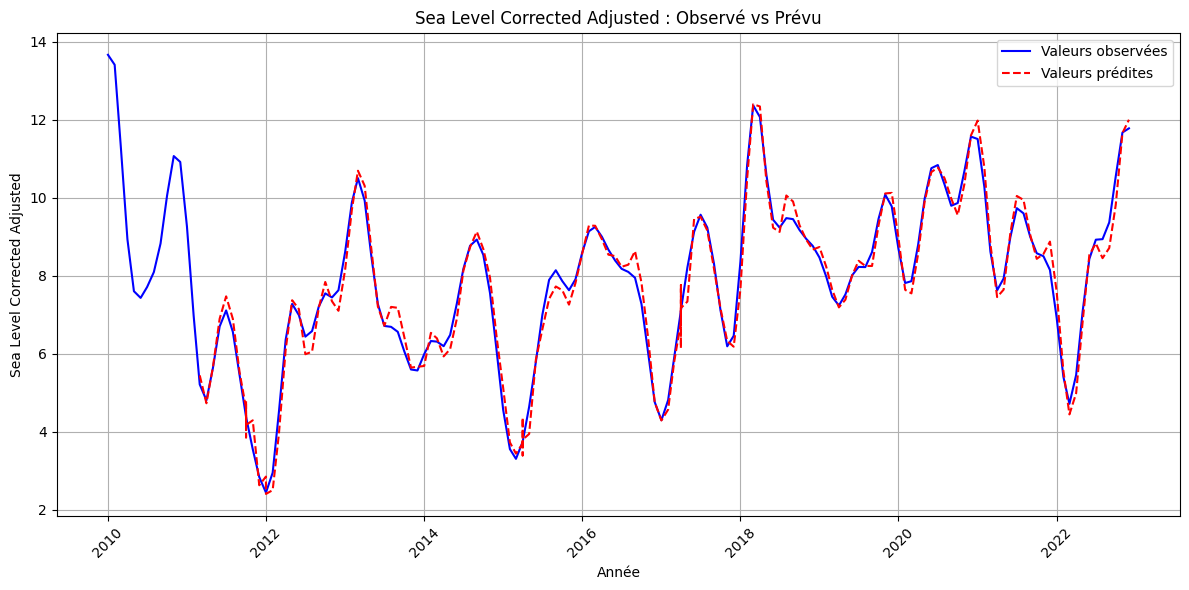

In [52]:

# Tracé des séries initiales et prédites
plt.figure(figsize=(12, 6))
plt.plot(df['year_month'], df['sea level corrected adjusted'], label='Valeurs observées', color='blue')
plt.plot(df['year_month'], df['predicted_sea_level_corrected_adjusted'], label='Valeurs prédites', color='red', linestyle='--')

plt.title("Sea Level Corrected Adjusted : Observé vs Prévu")
plt.xlabel("Année")
plt.ylabel("Sea Level Corrected Adjusted")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [53]:
df['year_month'] = df1['year_month']

In [54]:
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y-%m-%d')

In [55]:
forecast_df.head(15)  # Afficher les prévisions

,sea level corrected adjusted_diff,greenland_mass_diff,salinité_seasonal_diff
482,-1.436507,-38.116460,0.016841
483,-0.784667,-30.782337,0.012815
484,0.132932,-16.494335,0.000555
485,0.722487,-12.238821,-0.012304
486,0.743548,-17.407960,-0.018735
487,0.348779,-23.633844,-0.017229
488,-0.118726,-25.302036,-0.011008
489,-0.375758,-22.486273,-0.004603
490,-0.339652,-18.407563,-0.001017
491,-0.114885,-16.031254,-0.000785


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168 entries, 336 to 503
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   sea level corrected adjusted            168 non-null    float64       
 1   chlorophylle                            168 non-null    float64       
 2   sst_anomaly_filtered                    168 non-null    float64       
 3   CO2                                     168 non-null    float64       
 4   salinité                                168 non-null    float64       
 5   greenland_mass                          168 non-null    float64       
 6   antarctica_mass                         168 non-null    float64       
 7   chlorophylle_seasonal_diff              156 non-null    float64       
 8   CO2_seasonal_diff                       156 non-null    float64       
 9   salinité_seasonal_diff                  156 non-null    f

In [57]:
import pandas as pd
import numpy as np

# Coefficients du modèle VAR
beta_0 = 0.0053
beta_1 = 1.2155
beta_2 = -0.5266
beta_3 = -0.0011
beta_4 = -0.0087
beta_5 = 0.7743
beta_6 = 3.0647
gamma_1 = -0.7518
gamma_2 = 0.1543
gamma_3 = -0.0002
gamma_4 = 0.0023
gamma_5 = -1.7930
gamma_6 = -2.2386

# Sélectionner les variables pour le VAR
var_df = df[[
    'year_month',
    'sea level corrected adjusted_diff',
    'sst_anomaly_filtered_diff',
    'greenland_mass_diff',
    'CO2_seasonal_diff',
    'chlorophylle_seasonal_diff',
    'salinité_seasonal_diff'
]].dropna()

# Ajuster le modèle VAR avec un lag de 2
model = VAR(var_df.drop(columns=['year_month']))
var_model = model.fit(2)

# Calculer les valeurs différenciées prédictes
predicted_diff = beta_0 + beta_1 * var_df['sea level corrected adjusted_diff'].shift(1) + \
                 beta_2 * var_df['sst_anomaly_filtered_diff'].shift(1) + \
                 beta_3 * var_df['greenland_mass_diff'].shift(1) + \
                 beta_4 * var_df['CO2_seasonal_diff'].shift(1) + \
                 beta_5 * var_df['chlorophylle_seasonal_diff'].shift(1) + \
                 beta_6 * var_df['salinité_seasonal_diff'].shift(1) + \
                 gamma_1 * var_df['sea level corrected adjusted_diff'].shift(2) + \
                 gamma_2 * var_df['sst_anomaly_filtered_diff'].shift(2) + \
                 gamma_3 * var_df['greenland_mass_diff'].shift(2) + \
                 gamma_4 * var_df['CO2_seasonal_diff'].shift(2) + \
                 gamma_5 * var_df['chlorophylle_seasonal_diff'].shift(2) + \
                 gamma_6 * var_df['salinité_seasonal_diff'].shift(2)

# Convertir les valeurs différenciées en niveaux
predicted_levels = df['sea level corrected adjusted'].shift(1) + predicted_diff

# Vérifier les valeurs manquantes
print(f"Nombre de valeurs manquantes dans les prédictions: {predicted_levels.isna().sum()}")

# Ajouter les valeurs prédites au DataFrame
df['predicted_sea_level_corrected_adjusted'] = predicted_levels

# Afficher les résultats
print(df[['year_month', 'sea level corrected adjusted', 'predicted_sea_level_corrected_adjusted']])


Nombre de valeurs manquantes dans les prédictions: 14
    year_month  sea level corrected adjusted  \
336 2010-01-01                     13.668426   
337 2010-02-01                     13.412240   
338 2010-03-01                     11.343056   
339 2010-04-01                      8.935583   
340 2010-05-01                      7.603814   
..         ...                           ...   
499 2022-08-01                      8.939324   
500 2022-09-01                      9.370107   
501 2022-10-01                     10.550028   
502 2022-11-01                     11.676192   
503 2022-12-01                     11.781491   

     predicted_sea_level_corrected_adjusted  
336                                     NaN  
337                                     NaN  
338                                     NaN  
339                                     NaN  
340                                     NaN  
..                                      ...  
499                                8.456352  
5

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
